# Part 11: Handling Missing Observations with Filters and Smoothers

In real data, observations are often missing. A sensor might fail for a while, an experiment might stop and restart, or measurements may occur asynchronously or at different frequencies. This notebook covers those cases using `Filter` and `Smoother` for inference.

| Section | Missingness pattern | Inference path used here |
|---|---|---|
| 3 | Entire rows missing: all dimensions are `NaN` at some timesteps | cuthbert Kalman `Filter` and `Smoother` |
| 4 | Partial rows missing: some dimensions are `NaN` within a row | cuthbert Kalman `Filter` and `Smoother` |

Rules to keep in mind:

- Use `NaN` values in `obs_values` to mark missing observations.
- `obs_times`, `ctrl_times`, `predict_times`, and `ctrl_values` must remain finite
- CD-Dynamax backends do **not** accept `NaN` observations
- In this notebook, missing-data handling uses the discrete-time cuthbert Kalman filter/smoother path.

The upshot:
- If your `i`'th measurement is missing at some time `obs_times[k]`, just let `obs_values[k,i] = jnp.nan`.
- This works automatically for the following discrete-time filtering/smoothing algorithms that use cuthbert backends:
    - Kalman Filter/Smoother
    - Ensemble Kalman Filter
- It also works for cuthbert Particle Filter / Smoother, but only if you do some extra work to ensure that the transition and observation functions handle `NaN` appropriately (not covered in this tutorial).

In [1]:
import time

import arviz as az
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import seaborn as sns
from numpyro.handlers import seed
from numpyro.infer import MCMC, NUTS, Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, Filter, Smoother
from dynestyx.inference.configs.filter import KFConfig, EKFConfig
from dynestyx.inference.configs.smoother import KFSmootherConfig
from dynestyx.models import DynamicalModel, LinearGaussianObservation, LinearGaussianStateEvolution

az.style.use("arviz-white")


def summarize_gaussian_mixture(mean_samples, cov_diag_samples, *, rng_key, inner_draws=8):
    """Approximate the full posterior predictive state distribution.

    The posterior over states is a mixture of Gaussians: each posterior draw of
    the parameters contributes a Gaussian filtered/smoothed state posterior with
    its own mean and covariance. We sample from those conditional Gaussians so
    that the 90% interval includes both parameter uncertainty and state
    uncertainty.
    """
    mean_samples = np.asarray(mean_samples)
    cov_diag_samples = np.asarray(cov_diag_samples)
    std_samples = np.sqrt(np.clip(cov_diag_samples, a_min=0.0, a_max=None))

    z = np.asarray(jr.normal(rng_key, shape=(inner_draws,) + mean_samples.shape))
    state_draws = mean_samples[None, ...] + std_samples[None, ...] * z
    state_draws = state_draws.reshape((-1,) + mean_samples.shape[1:])

    return {
        "mean": mean_samples.mean(axis=0),
        "lo": np.percentile(state_draws, 5, axis=0),
        "hi": np.percentile(state_draws, 95, axis=0),
        "parameter_only_lo": np.percentile(mean_samples, 5, axis=0),
        "parameter_only_hi": np.percentile(mean_samples, 95, axis=0),
        "avg_conditional_std": np.sqrt(cov_diag_samples.mean(axis=0)),
    }


## 1. The model

We use the same 2-D AR(1) state-space model shape as the original tutorial:

$$
\begin{aligned}
x_0 &\sim \mathcal{N}(0,\, I_2) \\[4pt]
x_{t+1} &\sim \mathcal{N}\!\left(\begin{pmatrix}\alpha & 0.2 \\ -0.1 & 0.8\end{pmatrix} x_t,\;\; \begin{pmatrix}0.1 & 0.01\\-0.01 & 0.15\end{pmatrix}\right) \\[4pt]
y_t &\sim \mathcal{N}(x_t,\; \mathrm{diag}(0.25, 0.25))
\end{aligned}
$$

The single unknown is $\alpha \in (-0.7, 0.7)$, the first dimension's autocorrelation. We set the true value to $\alpha^* = 0.4$.

The observation covariance is diagonal, which keeps the partial-missingness story close to the original notebook while remaining compatible with the cuthbert Kalman path used below.


In [2]:
obs_times = jnp.arange(0.0, 100.0, 1.0)
true_alpha = 0.4
state_dim = 2


def ar1_model(obs_times=None, obs_values=None, predict_times=None):
    alpha = numpyro.sample("alpha", dist.Uniform(-0.7, 0.7))

    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            jnp.zeros(state_dim), jnp.eye(state_dim)
        ),
        state_evolution=LinearGaussianStateEvolution(
            A=jnp.array([[alpha, 0.2], [-0.1, 0.8]]),
            cov=jnp.array([[0.1, 0.01], [-0.01, 0.15]]),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.eye(state_dim),
            R=jnp.diag(jnp.array([0.25, 0.25])),
        ),
        control_dim=0,
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


## 2. Generating synthetic data

We fix $\alpha = 0.4$ and draw one synthetic trajectory. As in the original notebook, the inference sections below will condition on noisy observations, but the simulator is only used here to create the synthetic dataset.


In [3]:
data_key, mcmc_key1, mcmc_key2, mcmc_key3, mcmc_key4, pp_key = jr.split(jr.PRNGKey(0), 6)

n_mcmc_warmup = 800
n_mcmc_samples = 800

with DiscreteTimeSimulator():
    synthetic = Predictive(
        ar1_model,
        params={"alpha": jnp.array(true_alpha)},
        num_samples=1,
        exclude_deterministic=False,
    )(data_key, predict_times=obs_times)

states_clean = np.asarray(synthetic["f_states"].squeeze((0, 1)))
obs_clean = np.asarray(synthetic["f_observations"].squeeze((0, 1)))
t = np.asarray(obs_times)


/var/folders/fx/6n6838cn51v4zyntllq4rxq80000gn/T/ipykernel_66173/671367118.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


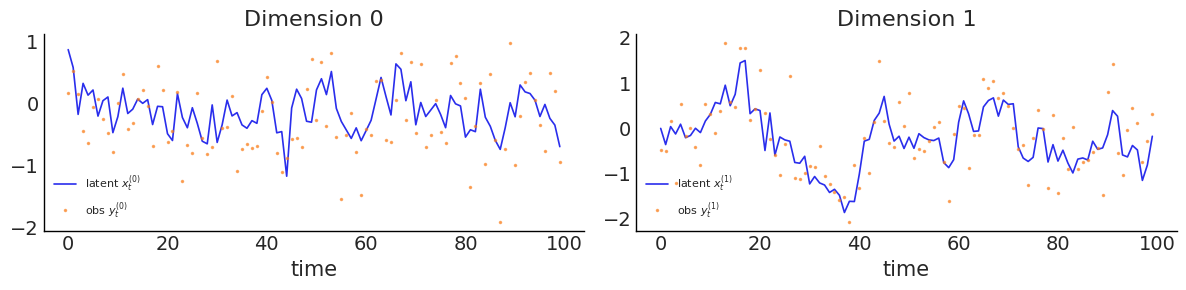

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=False)
for d, ax in enumerate(axes):
    ax.plot(t, states_clean[:, d], color="C0", lw=1.2, label=f"latent $x^{{({d})}}_t$")
    ax.plot(t, obs_clean[:, d], ".", ms=3, color="C1", alpha=0.6, label=f"obs $y^{{({d})}}_t$")
    ax.set_xlabel("time")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=8)
# fig.suptitle("Clean synthetic data  ($\alpha^* = 0.4$)", fontsize=12)
plt.tight_layout()
plt.show()


## 3. Whole-row missingness

A **whole-row missing** observation means all $d_y$ dimensions are `NaN` at that timestep. We blank out a contiguous block in the middle of the series, just as in the original notebook.


/var/folders/fx/6n6838cn51v4zyntllq4rxq80000gn/T/ipykernel_66173/462746365.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


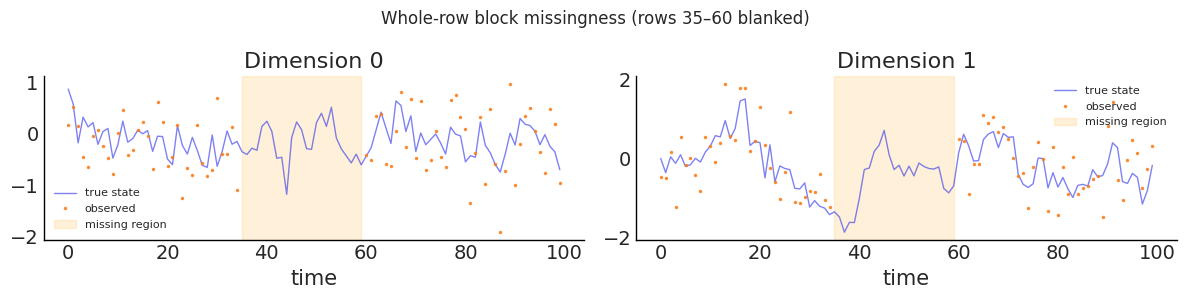

In [5]:
block_start, block_end = 35, 60

obs_block = np.where(
    (np.arange(len(t))[:, None] >= block_start)
    & (np.arange(len(t))[:, None] < block_end),
    np.nan,
    obs_clean,
)
obs_block = jnp.array(obs_block)


def _shade_gap(ax, t, start, end):
    ax.axvspan(t[start], t[end - 1], color="orange", alpha=0.15, zorder=0, label="missing region")


fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=False)
for d, ax in enumerate(axes):
    ax.plot(t, states_clean[:, d], color="C0", lw=1.0, alpha=0.6, label="true state")
    obs_d = np.asarray(obs_block[:, d])
    ax.plot(t[~np.isnan(obs_d)], obs_d[~np.isnan(obs_d)], ".", ms=3, color="C1", alpha=0.8, label="observed")
    _shade_gap(ax, t, block_start, block_end)
    ax.set_xlabel("time")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=8)
fig.suptitle("Whole-row block missingness (rows 35–60 blanked)", fontsize=12)
plt.tight_layout()
plt.show()


### 3.1 The filtering path

With `Filter`, inference proceeds through the exact cuthbert Kalman marginal likelihood. No latent state trajectory is sampled inside NUTS; instead, we infer $\alpha$ and then recover posterior filtered state summaries with posterior predictive evaluation.


In [6]:
def conditioned_filter(obs_times=None, obs_values=None):
    with Filter(
        filter_config=KFConfig(
            filter_source="cuthbert",
            record_filtered_states_mean=True,
            record_filtered_states_cov_diag=True,
        )
    ):
        ar1_model(obs_times=obs_times, obs_values=obs_values)


t0 = time.time()
mcmc_filter_block = MCMC(
    NUTS(conditioned_filter),
    num_warmup=n_mcmc_warmup,
    num_samples=n_mcmc_samples,
    progress_bar=False,
)
mcmc_filter_block.run(mcmc_key1, obs_times=obs_times, obs_values=obs_block)
filter_block_runtime = time.time() - t0

with Filter(
    filter_config=KFConfig(
        filter_source="cuthbert",
        record_filtered_states_mean=True,
        record_filtered_states_cov_diag=True,
    )
):
    pp_filter_block = Predictive(
        ar1_model,
        posterior_samples=mcmc_filter_block.get_samples(),
        exclude_deterministic=False,
    )(pp_key, obs_times=obs_times, obs_values=obs_block)

posterior_alpha_filter_block = np.asarray(mcmc_filter_block.get_samples()["alpha"])
filtered_states_block = np.asarray(pp_filter_block["f_filtered_states_mean"])
filtered_cov_diag_block = np.asarray(pp_filter_block["f_filtered_states_cov_diag"])
filtered_summary_block = summarize_gaussian_mixture(
    filtered_states_block,
    filtered_cov_diag_block,
    rng_key=jr.fold_in(pp_key, 10),
)
filtered_mean_block = filtered_summary_block["mean"]
filtered_lo_block = filtered_summary_block["lo"]
filtered_hi_block = filtered_summary_block["hi"]

print(f"Filter runtime: {filter_block_runtime:.2f}s")


Filter runtime: 46.57s


### 3.2 The smoothing path

`Smoother` uses the same marginal likelihood for parameter inference, but the posterior state summaries now approximate $p(x_t \mid y_{1:T})$ rather than $p(x_t \mid y_{1:t})$. This is especially useful across the missing block, because later observations can inform the states inside the gap.


In [7]:
def conditioned_smoother(obs_times=None, obs_values=None):
    with Smoother(
        smoother_config=KFSmootherConfig(
            filter_source="cuthbert",
            record_smoothed_states_mean=True,
            record_smoothed_states_cov_diag=True,
        )
    ):
        ar1_model(obs_times=obs_times, obs_values=obs_values)


t0 = time.time()
mcmc_smoother_block = MCMC(
    NUTS(conditioned_smoother),
    num_warmup=n_mcmc_warmup,
    num_samples=n_mcmc_samples,
    progress_bar=False,
)
mcmc_smoother_block.run(mcmc_key2, obs_times=obs_times, obs_values=obs_block)
smoother_block_runtime = time.time() - t0

with Smoother(
    smoother_config=KFSmootherConfig(
        filter_source="cuthbert",
        record_smoothed_states_mean=True,
        record_smoothed_states_cov_diag=True,
    )
):
    pp_smoother_block = Predictive(
        ar1_model,
        posterior_samples=mcmc_smoother_block.get_samples(),
        exclude_deterministic=False,
    )(jr.fold_in(pp_key, 1), obs_times=obs_times, obs_values=obs_block)

posterior_alpha_smoother_block = np.asarray(mcmc_smoother_block.get_samples()["alpha"])
smoothed_states_block = np.asarray(pp_smoother_block["f_smoothed_states_mean"])
smoothed_cov_diag_block = np.asarray(pp_smoother_block["f_smoothed_states_cov_diag"])
smoothed_summary_block = summarize_gaussian_mixture(
    smoothed_states_block,
    smoothed_cov_diag_block,
    rng_key=jr.fold_in(pp_key, 11),
)
smoothed_mean_block = smoothed_summary_block["mean"]
smoothed_lo_block = smoothed_summary_block["lo"]
smoothed_hi_block = smoothed_summary_block["hi"]

print(f"Smoother runtime: {smoother_block_runtime:.2f}s")


Smoother runtime: 14.16s


### 3.3 Comparing posteriors

The posterior over $\alpha$ should be similar, because both handlers add the same marginal log-likelihood.

For the state bands, we now use the recorded filtered/smoothed covariance diagonals as well as the posterior spread in the filtered/smoothed means. The 90% intervals below therefore describe the **full posterior predictive state uncertainty**, not just the between-parameter variation in the means.


/var/folders/fx/6n6838cn51v4zyntllq4rxq80000gn/T/ipykernel_66173/2199828210.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


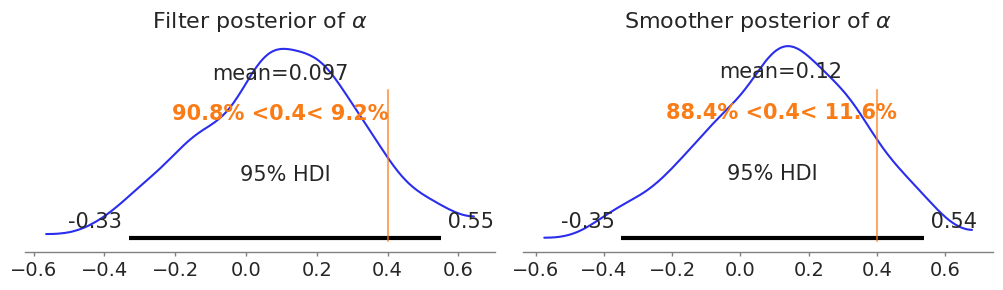

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
az.plot_posterior(posterior_alpha_filter_block, hdi_prob=0.95, ref_val=true_alpha, ax=axes[0])
axes[0].set_title("Filter posterior of $\\alpha$")
az.plot_posterior(posterior_alpha_smoother_block, hdi_prob=0.95, ref_val=true_alpha, ax=axes[1])
axes[1].set_title("Smoother posterior of $\\alpha$")
plt.tight_layout()
plt.show()


/var/folders/fx/6n6838cn51v4zyntllq4rxq80000gn/T/ipykernel_66173/3918325534.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


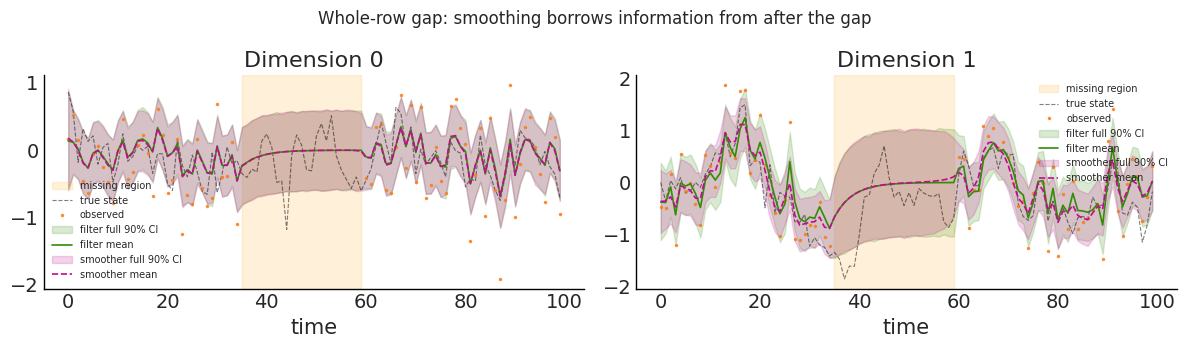

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=False)
for d, ax in enumerate(axes):
    _shade_gap(ax, t, block_start, block_end)
    ax.plot(t, states_clean[:, d], color="black", lw=0.8, ls="--", alpha=0.5, label="true state")
    obs_d = np.asarray(obs_block[:, d])
    ax.plot(t[~np.isnan(obs_d)], obs_d[~np.isnan(obs_d)], ".", ms=3, color="C1", alpha=0.8, label="observed")
    ax.fill_between(t, filtered_lo_block[:, d], filtered_hi_block[:, d], color="C2", alpha=0.18, label="filter full 90% CI")
    ax.plot(t, filtered_mean_block[:, d], color="C2", lw=1.2, label="filter mean")
    ax.fill_between(t, smoothed_lo_block[:, d], smoothed_hi_block[:, d], color="C3", alpha=0.18, label="smoother full 90% CI")
    ax.plot(t, smoothed_mean_block[:, d], color="C3", lw=1.2, ls="--", label="smoother mean")
    ax.set_xlabel("time")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=7)
fig.suptitle("Whole-row gap: smoothing borrows information from after the gap", fontsize=12)
plt.tight_layout()
plt.show()


## 4. Per-dimension partial missingness

A **partial** observation has some dimensions observed and others `NaN` within the same row. We keep the same diagonal-observation AR(1) model and randomly blank individual entries.

When the data array contains per-dimension `NaN` values, dynestyx now routes this through the cuthbert Kalman path shown here. No `NaN` values are allowed in any `*_times` arrays or in `ctrl_values`.


In [10]:
partial_key = jr.PRNGKey(7)
mask_partial = jr.bernoulli(partial_key, p=0.8, shape=obs_clean.shape)
obs_partial = jnp.where(mask_partial, jnp.array(obs_clean), jnp.nan)

nan_any = jnp.isnan(obs_partial).any(axis=1)
nan_all = jnp.isnan(obs_partial).all(axis=1)
n_partial_rows = int((nan_any & ~nan_all).sum())
print(f"Rows with at least one NaN:      {int(nan_any.sum())}")
print(f"  of which partial (not all-NaN): {n_partial_rows}")
print(f"  of which fully missing:         {int(nan_all.sum())}")


Rows with at least one NaN:      37
  of which partial (not all-NaN): 34
  of which fully missing:         3


/var/folders/fx/6n6838cn51v4zyntllq4rxq80000gn/T/ipykernel_66173/3992659053.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


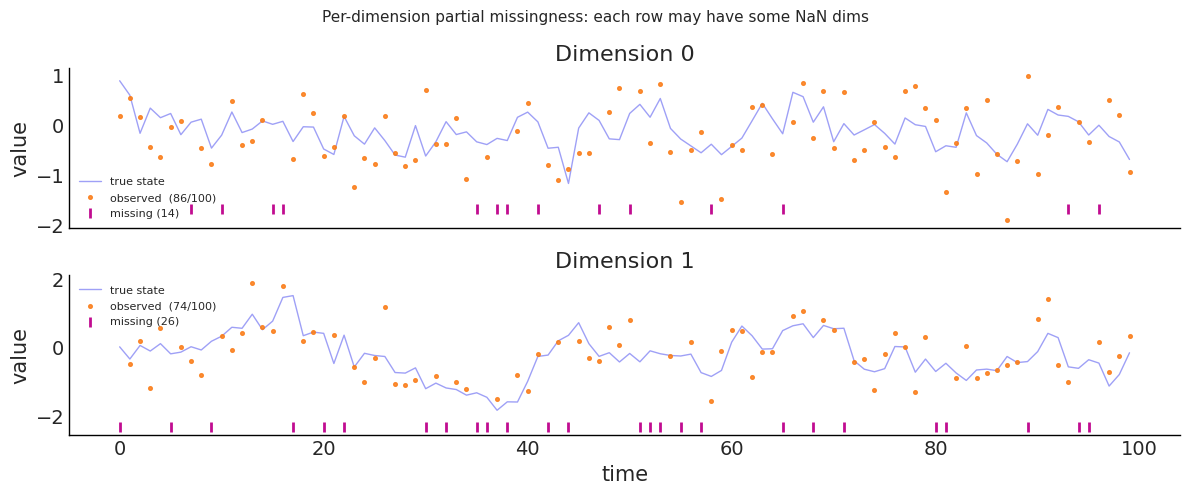

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for d, ax in enumerate(axes):
    obs_d = np.asarray(obs_partial[:, d])
    missing = np.isnan(obs_d)
    ax.plot(t, states_clean[:, d], color="C0", lw=1.0, alpha=0.45, label="true state")
    ax.scatter(t[~missing], obs_d[~missing], s=7, color="C1", alpha=0.85, zorder=3, label=f"observed  ({(~missing).sum()}/{len(t)})")
    ylo = np.nanmin(states_clean[:, d]) - 0.5
    ax.scatter(t[missing], np.full(missing.sum(), ylo), s=50, marker="|", color="C3", linewidths=2, zorder=4, label=f"missing ({missing.sum()})")
    ax.set_ylabel("value")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=8)
axes[-1].set_xlabel("time")
fig.suptitle("Per-dimension partial missingness: each row may have some NaN dims", fontsize=11)
plt.tight_layout()
plt.show()


In [12]:
mcmc_filter_partial = MCMC(
    NUTS(conditioned_filter),
    num_warmup=n_mcmc_warmup,
    num_samples=n_mcmc_samples,
    progress_bar=False,
)
mcmc_filter_partial.run(mcmc_key3, obs_times=obs_times, obs_values=obs_partial)

mcmc_smoother_partial = MCMC(
    NUTS(conditioned_smoother),
    num_warmup=n_mcmc_warmup,
    num_samples=n_mcmc_samples,
    progress_bar=False,
)
mcmc_smoother_partial.run(mcmc_key4, obs_times=obs_times, obs_values=obs_partial)

with Filter(
    filter_config=KFConfig(
        filter_source="cuthbert",
        record_filtered_states_mean=True,
        record_filtered_states_cov_diag=True,
    )
):
    pp_filter_partial = Predictive(
        ar1_model,
        posterior_samples=mcmc_filter_partial.get_samples(),
        exclude_deterministic=False,
    )(jr.fold_in(pp_key, 2), obs_times=obs_times, obs_values=obs_partial)

with Smoother(
    smoother_config=KFSmootherConfig(
        filter_source="cuthbert",
        record_smoothed_states_mean=True,
        record_smoothed_states_cov_diag=True,
    )
):
    pp_smoother_partial = Predictive(
        ar1_model,
        posterior_samples=mcmc_smoother_partial.get_samples(),
        exclude_deterministic=False,
    )(jr.fold_in(pp_key, 3), obs_times=obs_times, obs_values=obs_partial)

posterior_alpha_filter_partial = np.asarray(mcmc_filter_partial.get_samples()["alpha"])
posterior_alpha_smoother_partial = np.asarray(mcmc_smoother_partial.get_samples()["alpha"])

filtered_states_partial = np.asarray(pp_filter_partial["f_filtered_states_mean"])
filtered_cov_diag_partial = np.asarray(pp_filter_partial["f_filtered_states_cov_diag"])
filtered_summary_partial = summarize_gaussian_mixture(
    filtered_states_partial,
    filtered_cov_diag_partial,
    rng_key=jr.fold_in(pp_key, 12),
)
filtered_mean_partial = filtered_summary_partial["mean"]
filtered_lo_partial = filtered_summary_partial["lo"]
filtered_hi_partial = filtered_summary_partial["hi"]

smoothed_states_partial = np.asarray(pp_smoother_partial["f_smoothed_states_mean"])
smoothed_cov_diag_partial = np.asarray(pp_smoother_partial["f_smoothed_states_cov_diag"])
smoothed_summary_partial = summarize_gaussian_mixture(
    smoothed_states_partial,
    smoothed_cov_diag_partial,
    rng_key=jr.fold_in(pp_key, 13),
)
smoothed_mean_partial = smoothed_summary_partial["mean"]
smoothed_lo_partial = smoothed_summary_partial["lo"]
smoothed_hi_partial = smoothed_summary_partial["hi"]


/var/folders/fx/6n6838cn51v4zyntllq4rxq80000gn/T/ipykernel_66173/770947751.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


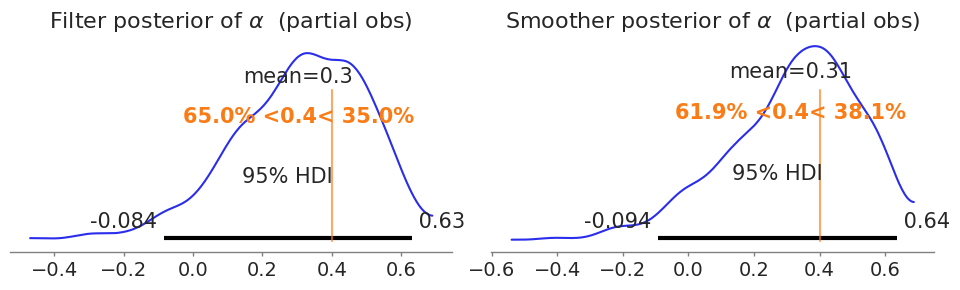

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
az.plot_posterior(posterior_alpha_filter_partial, hdi_prob=0.95, ref_val=true_alpha, ax=axes[0])
axes[0].set_title("Filter posterior of $\\alpha$  (partial obs)")
az.plot_posterior(posterior_alpha_smoother_partial, hdi_prob=0.95, ref_val=true_alpha, ax=axes[1])
axes[1].set_title("Smoother posterior of $\\alpha$  (partial obs)")
plt.tight_layout()
plt.show()


/var/folders/fx/6n6838cn51v4zyntllq4rxq80000gn/T/ipykernel_66173/2704678041.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


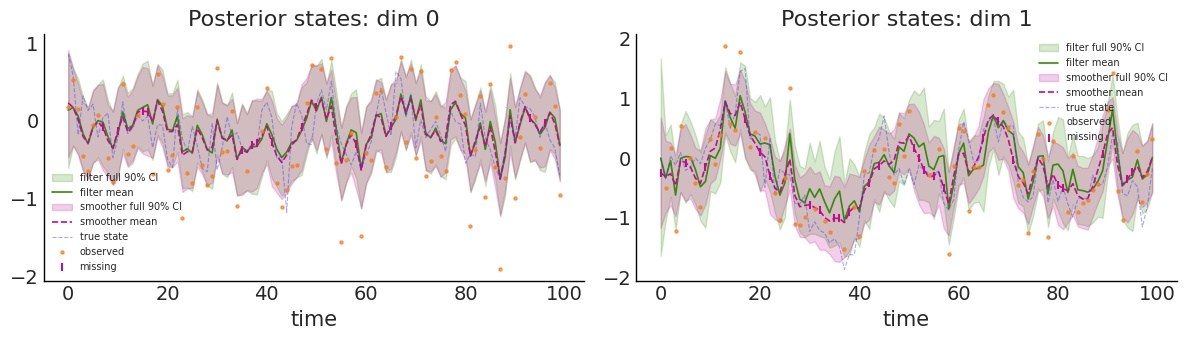

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=False)
for d, ax in enumerate(axes):
    obs_d = np.asarray(obs_partial[:, d])
    missing = np.isnan(obs_d)
    ax.fill_between(t, filtered_lo_partial[:, d], filtered_hi_partial[:, d], color="C2", alpha=0.2, label="filter full 90% CI")
    ax.plot(t, filtered_mean_partial[:, d], color="C2", lw=1.2, label="filter mean")
    ax.fill_between(t, smoothed_lo_partial[:, d], smoothed_hi_partial[:, d], color="C3", alpha=0.2, label="smoother full 90% CI")
    ax.plot(t, smoothed_mean_partial[:, d], color="C3", lw=1.2, ls="--", label="smoother mean")
    ax.plot(t, states_clean[:, d], color="C0", lw=0.8, ls="--", alpha=0.4, label="true state")
    ax.scatter(t[~missing], obs_d[~missing], s=5, color="C1", alpha=0.7, zorder=3, label="observed")
    ax.scatter(t[missing], smoothed_mean_partial[missing, d], s=30, marker="|", color="C3", linewidths=1.5, zorder=4, label="missing")
    ax.set_title(f"Posterior states: dim {d}")
    ax.set_xlabel("time")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


## Summary

| Section | Missingness pattern | Key mechanism in this branch |
|---|---|---|
| 3 | Whole-row contiguous gap | `NaN` rows in `obs_values`, cuthbert Kalman `Filter`/`Smoother` |
| 4 | Per-dimension partial missingness | `NaN` coordinates in `obs_values`, same cuthbert Kalman path |

The main difference between the two handlers is interpretive rather than probabilistic: both use the same marginal likelihood to infer $\alpha$, but `Smoother` conditions every latent state on the full observation window and therefore produces better retrospective reconstructions inside missing regions.

The plotted 90% bands now use both the posterior spread in the filtered/smoothed means and the recorded filtered/smoothed covariance diagonals, so they better approximate the full posterior predictive state uncertainty.

These missing-data examples are specific to the cuthbert Gaussian filter/smoother path shown here. If your observation family is not supported by this route, or if partial missingness does not admit a simple masked likelihood formula, the fallback is now **explicit missing-observation augmentation** under `LatentPathBuilder`; see Part 11b for the correlated Student $t$ example.

The missing-data support demonstrated here does **not** extend to `NaN` values in any `*_times` arrays or in `ctrl_values`, and it does not apply to CD-Dynamax backends.

